##### Parallelization Workflow

In [27]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel, Field
from typing import TypedDict, Annotated
from IPython.display import display, Image
import operator

In [5]:
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

In [4]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description = 'Detailed feedback for the essay')
    score: int = Field(description='Score out of 10', le=10, gt=0)

In [6]:
structured_model = model.with_structured_output(EvaluationSchema)

In [9]:
class UPSCState(TypedDict):
    essay: str
    language_feedback: str
    clarity_feedback: str
    analysis_feedback: str
    individual_scores: Annotated[list[int], operator.add] # since, all 3 nodes provide their individual score, so we collect all scores in a list by the help of reducer function
    avg_score: float


In [23]:
essay = f"""
Technology has emerged as one of the strongest drivers of inclusive development in the 21st century. It has transformed governance, education, healthcare, agriculture, and financial services by making them more accessible and efficient. Digital platforms have enabled governments to deliver welfare benefits directly to beneficiaries, reducing leakages and improving transparency.

In education, online learning resources have expanded access to quality content, while telemedicine has improved healthcare delivery in remote regions. Farmers benefit from weather forecasts, market information, and precision agriculture, helping them make informed decisions. Similarly, digital payment systems have promoted financial inclusion by bringing millions into the formal banking network.

However, technology alone cannot guarantee inclusion. The digital divide, inadequate infrastructure, lack of digital literacy, and concerns regarding data privacy continue to exclude vulnerable sections of society. Without addressing these challenges, technological progress may widen existing inequalities.

Therefore, inclusive development requires a balanced approach that combines technological innovation with equitable access, robust institutions, and effective policy implementation. Investments in digital infrastructure, skill development, and cybersecurity are essential to ensure that technology serves as a tool for empowerment rather than exclusion.

In conclusion, technology is not an end in itself but a means to achieve social and economic progress. When guided by ethical governance and inclusive policies, it has the potential to create a more equitable, prosperous, and resilient society.

"""

In [17]:
def evaluate_language(state: UPSCState):
    prompt = f'Evaluate the language quality of the given essay & provide a feedback and assign a score out of 10\n {state['essay']}'
    output = structured_model.invoke(prompt)

    return {'language_feedback':output.feedback, 'individual_scores':[output.score]}

In [15]:
def evaluate_thought(state: UPSCState):
    prompt = f'Evaluate the clarity of thought quality of the given essay & provide a feedback and assign a score out of 10\n {state['essay']}'
    output = structured_model.invoke(prompt)

    return {'clarity_feedback':output.feedback, 'individual_scores':[output.score]}

In [16]:
def evaluate_depth(state: UPSCState):
    prompt = f'Evaluate depth of analysis of the given essay & provide a feedback and assign a score out of 10\n {state['essay']}'
    output = structured_model.invoke(prompt)

    return {'analysis_feedback':output.feedback, 'individual_scores':[output.score]}

In [18]:
def final_evaluation(state: UPSCState):
    prompt = f'Based on the following feedbacks create a summarized feedback\n language feedback - {state['language_feedback']}\n depth of analysis feedback - {state['analysis_feedback']}\n clarity of thought feedback - {state['clarity_feedback']}'
    overall_feedback = model.invoke(prompt).content

    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])
    return {'overall_feedback':overall_feedback, 'avg_scores':[avg_score]}

In [25]:
graph = StateGraph(UPSCState)

graph.add_node('evaluate_lang', evaluate_language)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('evaluate_depth', evaluate_depth)
graph.add_node('final_evaluation', final_evaluation)

graph.add_edge(START, 'evaluate_lang')
graph.add_edge(START, 'evaluate_thought')
graph.add_edge(START, 'evaluate_depth')

graph.add_edge('evaluate_lang', 'final_evaluation')
graph.add_edge('evaluate_thought', 'final_evaluation')
graph.add_edge('evaluate_depth', 'final_evaluation')
graph.add_edge('final_evaluation', END)

workflow = graph.compile()

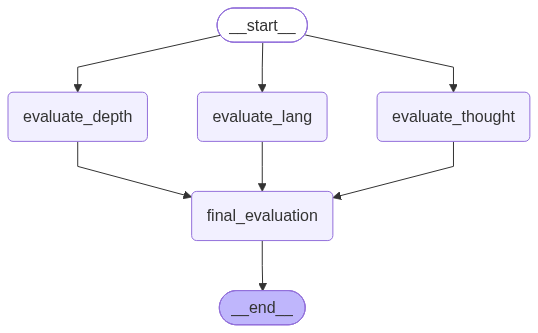

In [32]:
display(Image(workflow.get_graph(xray=True).draw_mermaid_png()))

In [24]:
initial_state = {
    'essay': essay
}

In [ ]:
print(workflow.invoke(initial_state))

{'essay': '\nTechnology has emerged as one of the strongest drivers of inclusive development in the 21st century. It has transformed governance, education, healthcare, agriculture, and financial services by making them more accessible and efficient. Digital platforms have enabled governments to deliver welfare benefits directly to beneficiaries, reducing leakages and improving transparency.\n\nIn education, online learning resources have expanded access to quality content, while telemedicine has improved healthcare delivery in remote regions. Farmers benefit from weather forecasts, market information, and precision agriculture, helping them make informed decisions. Similarly, digital payment systems have promoted financial inclusion by bringing millions into the formal banking network.\n\nHowever, technology alone cannot guarantee inclusion. The digital divide, inadequate infrastructure, lack of digital literacy, and concerns regarding data privacy continue to exclude vulnerable sectio